## MORE COMM DYN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class MRgnODE(nn.Module):
    def __init__(self, N=2, input_dim=2, tau=0.01, num_regions=1):
        super().__init__()
        self.N = N
        self.tau = tau
        self.num_regions = num_regions
        self.region_dim = N // num_regions if num_regions > 1 else N
        
        hidden_dim = 64
        
        if num_regions == 1:
            # Standard gnODE for single region
            self.flow_net = nn.Sequential(
                nn.Linear(N + input_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim), 
                nn.Tanh(),
                nn.Linear(hidden_dim, N)
            )
            
            self.gate_net = nn.Sequential(
                nn.Linear(N + input_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, N),
                nn.Sigmoid()
            )
        else:
            # Multi-region gnODE
            total_dim = num_regions * self.region_dim
            total_input_dim = num_regions * input_dim
            
            self.flow_net = nn.Sequential(
                nn.Linear(total_dim + total_input_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, total_dim)
            )
            
            self.gate_net = nn.Sequential(
                nn.Linear(total_dim + total_input_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, total_dim),
                nn.Sigmoid()
            )
            
            # Communication weights between regions
            self.comm_weights = nn.Parameter(torch.randn(num_regions, self.region_dim, self.region_dim) * 0.1)
            
            # Gating network for adaptive communication
            self.comm_gates = nn.Sequential(
                nn.Linear(2 * self.region_dim, 32),
                nn.Tanh(), 
                nn.Linear(32, self.region_dim),
                nn.Sigmoid()
            )
        
        self.apply(self._init_weights)
        self.to(device)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        
    def compute_communication(self, h):
        if self.num_regions == 1:
            return torch.zeros_like(h)
            
        batch_size = h.shape[0]
        h_regions = h.view(batch_size, self.num_regions, self.region_dim)
        comm_input = torch.zeros_like(h_regions)
        
        # Sophisticated gated communication like original
        for i in range(self.num_regions):
            for j in range(self.num_regions):
                if i != j:
                    # Concatenate regions for adaptive gating
                    h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                    gate = self.comm_gates(h_concat)
                    
                    # Apply communication weight and learned gate
                    message = torch.matmul(h_regions[:, j], self.comm_weights[i].T)
                    comm_input[:, i] += gate * message
                    
        return comm_input.view(batch_size, -1)
        
    def forward(self, h, x):
        if self.num_regions == 1:
            # Standard gnODE forward pass
            hx = torch.cat([h, x], dim=-1)
            flow = self.flow_net(hx)
            gate = self.gate_net(hx)
            h_dot = gate * (-h + flow) / self.tau
            comm = torch.zeros_like(h)
        else:
            # Multi-region forward pass
            comm = self.compute_communication(h)
            hx = torch.cat([h, x], dim=-1)
            flow = self.flow_net(hx) + comm
            gate = self.gate_net(hx)
            h_dot = gate * (-h + flow) / self.tau
            
        return h_dot, comm

def euler_step(model, h, x, dt):
    """Single Euler step for ODE integration"""
    h_dot, comm = model(h, x)
    return h + dt * h_dot, comm

def generate_flip_flop_data(task_type, n_trials=500, trial_length=100, n_channels=2, n_regions=1):
    """Generate data for flip-flop tasks with optional multi-region support"""
    data = []
    
    for trial_idx in range(n_trials):
        if n_regions == 1:
            # Standard single-region data generation
            inputs = np.zeros((trial_length, n_channels))
            targets = np.zeros((trial_length, n_channels))
            
            n_pulses = np.random.poisson(6)
            pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
            current_output = np.zeros(n_channels)
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        inputs[t] = pulse_vals
                        current_output = pulse_vals
                    else:
                        channel = np.random.randint(n_channels)
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                        
                        inputs[t, channel] = pulse_val
                        current_output[channel] = pulse_val
                
                targets[t] = current_output.copy()
                
        else:
            # Multi-region data generation
            inputs = np.zeros((trial_length, n_regions, n_channels))
            targets = np.zeros((trial_length, n_regions, n_channels))
            
            for region in range(n_regions):
                n_pulses = np.random.poisson(3)  # Fewer pulses per region
                pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
                current_output = np.zeros(n_channels)
                
                for t in range(trial_length):
                    if t in pulse_times:
                        if task_type == 'disk':
                            radius = np.random.uniform(1, 2)
                            angle = np.random.uniform(0, 2*np.pi)
                            pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                            inputs[t, region] = pulse_vals
                            current_output = pulse_vals
                        else:
                            channel = np.random.randint(n_channels)
                            if task_type == 'fixed':
                                pulse_val = np.random.choice([-1, 1])
                            elif task_type == 'square':
                                pulse_val = np.random.uniform(-1, 1)
                            elif task_type == 'rectangle':
                                pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                            
                            inputs[t, region, channel] = pulse_val
                            current_output[channel] = pulse_val
                    
                    targets[t, region] = current_output.copy()
        
        data.append((inputs, targets))
    
    return data

def create_batched_data(train_data, batch_size=32, num_regions=1):
    """Convert list of sequences to batched tensors - efficient like original"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

def train_mr_gnode(model, train_data, n_epochs=300, lr=1e-3, dt=0.01, batch_size=32, comm_penalty_lam=0.01):
    """Train Multi-Region gnODE - efficient like original"""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    # Pre-batch the data (like original)
    inputs_batched, targets_batched = create_batched_data(train_data, batch_size, model.num_regions)
    
    losses = []
    for epoch in tqdm(range(n_epochs), desc="Training MR-gnODE"):
        total_loss = 0
        
        for batch_inputs, batch_targets in zip(inputs_batched, targets_batched):
            optimizer.zero_grad()
            
            if model.num_regions == 1:
                # Single region - same as original
                batch_size_actual, seq_len, input_dim = batch_inputs.shape
                h = torch.zeros(batch_size_actual, model.N, device=device)
                outputs = []
                
                for t in range(seq_len):
                    x_t = batch_inputs[:, t]
                    h, _ = euler_step(model, h, x_t, dt)
                    outputs.append(h)
                
                outputs = torch.stack(outputs, dim=1)
                loss = nn.MSELoss()(outputs, batch_targets)
            else:
                # Multi-region
                batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
                total_dim = model.num_regions * model.region_dim
                h = torch.zeros(batch_size_actual, total_dim, device=device)
                outputs = []
                comm_penalty = 0
                for t in range(seq_len):
                    x_t = batch_inputs[:, t].view(batch_size_actual, -1)
                    h, comm = euler_step(model, h, x_t, dt)
                    comm_penalty = comm_penalty_lam + 0.01 * torch.norm(comm)

                    outputs.append(h.view(batch_size_actual, model.num_regions, model.region_dim))
                
                outputs = torch.stack(outputs, dim=1)
                loss = nn.MSELoss()(outputs, batch_targets) + comm_penalty
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.2e}")
    
    model.eval()
    return losses


def plot_flow_field(model, task_type='fixed', xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), grid_size=15, region_idx=None):
    """
    Plot flow field for single or multi-region gnODE models
    Updated to work with models that return (h_dot, comm) from forward pass
    
    Args:
        model: Trained model (single or multi-region) 
        task_type: Type of task for title
        xlim, ylim: Plot bounds
        grid_size: Resolution of flow field
        region_idx: Which region to plot (None = all regions, int = specific region)
    """
    model.eval()
    
    # Create grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    if model.num_regions == 1:
        # Single region model - original behavior
        U, V = np.zeros_like(X), np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    h = torch.tensor([[X[i,j], Y[i,j]]], dtype=torch.float32, device=device)
                    x_input = torch.zeros(1, 2, device=device)
                    h_dot, comm = model(h, x_input)
                    U[i,j] = h_dot[0,0].cpu().item()
                    V[i,j] = h_dot[0,1].cpu().item()
        
        # Plot single region
        plt.figure(figsize=(8, 8))
        plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.xlabel('Channel 1')
        plt.ylabel('Channel 2')
        plt.title(f'gnODE Flow Field - {task_type.capitalize()} Task')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.show()
        
    else:
        # Multi-region model
        if region_idx is not None:
            # Plot specific region
            U, V = np.zeros_like(X), np.zeros_like(Y)
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        # Initialize with zeros
                        h = torch.zeros(1, model.num_regions * model.region_dim, device=device)
                        # Set only the target region's state
                        h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                        # Input for all regions (could be sparse)
                        x_input = torch.zeros(1, model.num_regions * 2, device=device)
                        
                        h_dot, comm = model(h, x_input)
                        # Extract flow for target region only
                        U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                        V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
            
            plt.figure(figsize=(8, 8))
            plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
            plt.xlim(xlim)
            plt.ylim(ylim)
            plt.xlabel('Channel 1')
            plt.ylabel('Channel 2')
            plt.title(f'MR-gnODE Flow Field - {task_type.capitalize()} Task (Region {region_idx})')
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
            plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
            plt.show()
            
        else:
            # Plot all regions in subplots
            fig, axes = plt.subplots(1, model.num_regions, figsize=(8*model.num_regions, 8))
            if model.num_regions == 1:
                axes = [axes]  # Make it iterable
            
            for region_idx in range(model.num_regions):
                U, V = np.zeros_like(X), np.zeros_like(Y)
                
                with torch.no_grad():
                    for i in range(grid_size):
                        for j in range(grid_size):
                            h = torch.zeros(1, model.num_regions * model.region_dim, device=device)
                            h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                            x_input = torch.zeros(1, model.num_regions * 2, device=device)
                            
                            h_dot, comm = model(h, x_input)
                            U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                            V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
                
                axes[region_idx].quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
                axes[region_idx].set_xlim(xlim)
                axes[region_idx].set_ylim(ylim)
                axes[region_idx].set_xlabel('Channel 1')
                axes[region_idx].set_ylabel('Channel 2')
                axes[region_idx].set_title(f'Region {region_idx}')
                axes[region_idx].grid(True, alpha=0.3)
                axes[region_idx].axhline(y=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].axvline(x=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].set_aspect('equal')
            
            plt.suptitle(f'MR-gnODE Flow Fields - {task_type.capitalize()} Task')
            plt.tight_layout()
            plt.show()

# Example usage
# torch.manual_seed(42)
# np.random.seed(42)



Using device: cuda


In [2]:

# # Test with single region (equivalent to standard gnODE)
# print("Testing Single Region MR-gnODE...")
task_type = 'fixed'

# Generate data for single region
train_data = generate_flip_flop_data(task_type, n_trials=1000, n_regions=1)

# Create and train single-region model  
model = MRgnODE(N=2, input_dim=2, num_regions=1)
losses = train_mr_gnode(model, train_data, n_epochs=100, batch_size=64)

# Plot results
plot_flow_field(model, task_type, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final loss: {losses[-1]:.6f}")

Training MR-gnODE:   1%|█▎                                                                                                                                    | 1/100 [00:02<03:48,  2.31s/it]

Epoch 0, Loss: 0.700290, LR: 2.13e-04


Training MR-gnODE:   7%|█████████▍                                                                                                                            | 7/100 [00:16<03:39,  2.36s/it]


KeyboardInterrupt: 


Testing Multi-Region MR-gnODE...


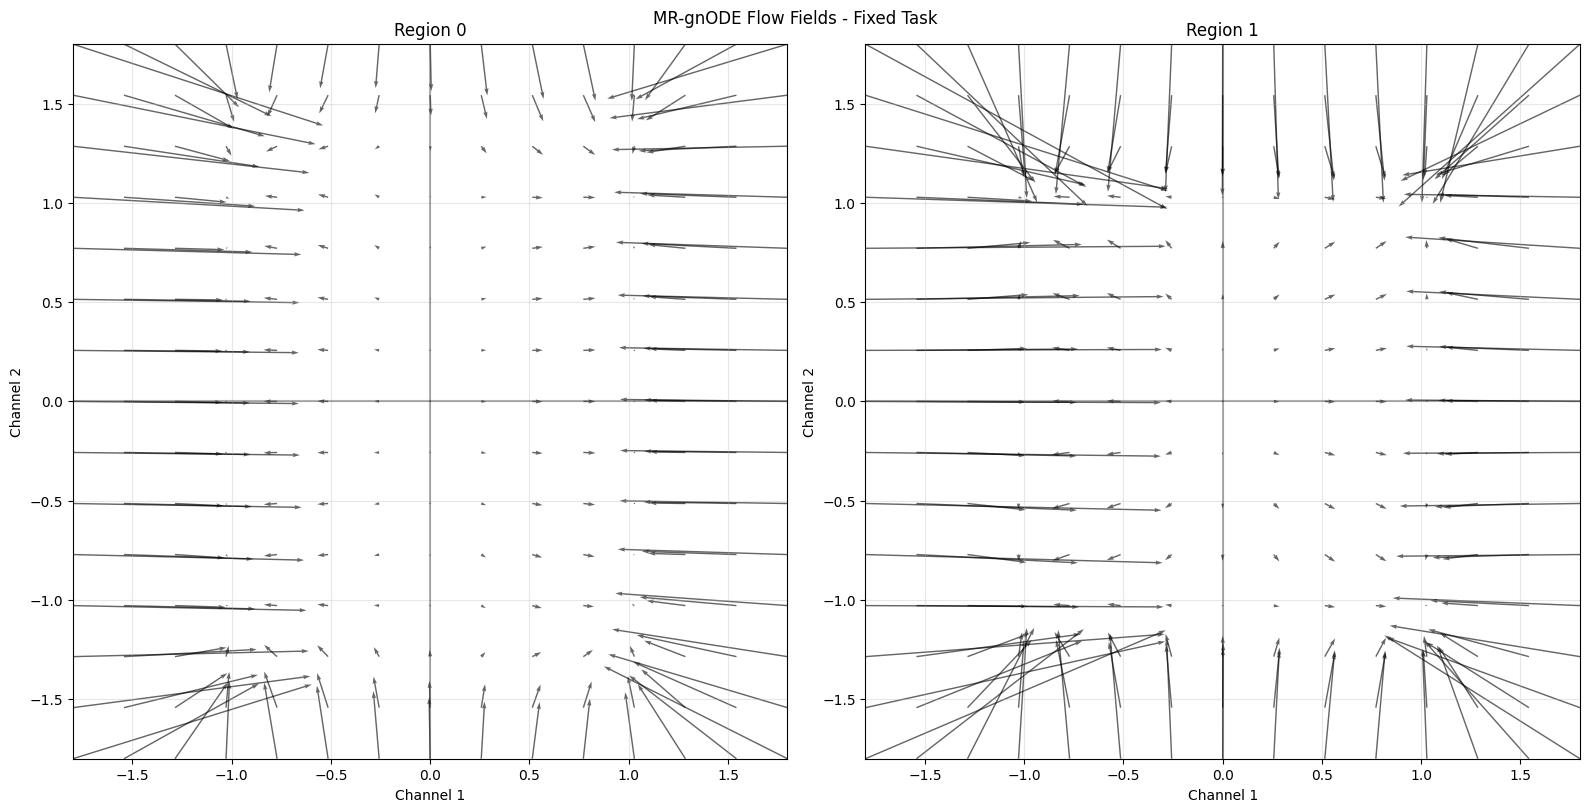

In [202]:

print("\nTesting Multi-Region MR-gnODE...")
# train_data_mr = generate_flip_flop_data(task_type, n_trials=500, n_regions=2)
# model_mr = MRgnODE(N=4, input_dim=2, num_regions=2)
# model_mr = torch.compile(model_mr)
# losses_mr = train_mr_gnode(model_mr, train_data_mr, n_epochs=200, lr=1e-3,batch_size=64)
plot_flow_field(model_mr, task_type, xlim=(-1.8, 1.8), ylim=(-1.8, 1.8))


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_communication(model, test_data, dt=0.01, device='cpu'):
    """
    Analyze communication patterns in trained multi-region gnODE
    """
    model.eval()
    
    if model.num_regions == 1:
        print("Single region model - no communication to analyze")
        return
    
    # Storage for analysis
    comm_magnitudes = []
    comm_matrices = []
    region_activities = []
    gate_activities = []
    
    with torch.no_grad():
        for trial_idx, (inputs, targets) in enumerate(test_data[:5]):  # Analyze first 5 trials
            inputs = torch.FloatTensor(inputs).unsqueeze(0).to(device)
            seq_len = inputs.shape[1]
            
            # Initialize
            h = torch.zeros(1, model.num_regions * model.region_dim, device=device)
            
            trial_comm_mag = []
            trial_comm_matrices = []
            trial_region_activity = []
            trial_gate_activity = []
            
            for t in range(seq_len):
                x_t = inputs[:, t].view(1, -1)
                
                # Forward step with communication tracking
                h_regions = h.view(1, model.num_regions, model.region_dim)
                
                # Track individual region activities
                region_activity = torch.norm(h_regions, dim=-1).squeeze().cpu().numpy()
                trial_region_activity.append(region_activity)
                
                # Compute communication with detailed tracking
                comm_matrix = np.zeros((model.num_regions, model.num_regions))
                gates_this_step = []
                
                if model.num_regions > 1:
                    for i in range(model.num_regions):
                        for j in range(model.num_regions):
                            if i != j:
                                # Get communication from j to i
                                h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                                gate = model.comm_gates(h_concat)
                                message = torch.matmul(h_regions[:, j], model.comm_weights[i].T)
                                comm_strength = torch.norm(gate * message).item()
                                comm_matrix[i, j] = comm_strength
                                gates_this_step.append(torch.mean(gate).item())
                
                trial_comm_matrices.append(comm_matrix)
                trial_gate_activity.append(np.mean(gates_this_step) if gates_this_step else 0)
                
                # Total communication magnitude
                comm = model.compute_communication(h)
                comm_magnitude = torch.norm(comm).item()
                trial_comm_mag.append(comm_magnitude)
                
                # Update hidden state
                h, comm = euler_step(model, h, x_t, dt)
            
            comm_magnitudes.append(trial_comm_mag)
            comm_matrices.append(trial_comm_matrices)
            region_activities.append(trial_region_activity)
            gate_activities.append(trial_gate_activity)
    
    return {
        'comm_magnitudes': np.array(comm_magnitudes),
        'comm_matrices': np.array(comm_matrices),
        'region_activities': np.array(region_activities),
        'gate_activities': np.array(gate_activities)
    }

def plot_communication_analysis(analysis_results, model):
    """
    Create comprehensive communication visualizations
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    region_activities = analysis_results['region_activities']
    gate_activities = analysis_results['gate_activities']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Communication magnitude over time
    axes[0, 0].plot(comm_mag.T, alpha=0.7)
    axes[0, 0].plot(np.mean(comm_mag, axis=0), 'k-', linewidth=3, label='Average')
    axes[0, 0].set_title('Communication Magnitude Over Time')
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('||Communication||')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Average communication matrix (region-to-region)
    avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
    im = axes[0, 1].imshow(avg_comm_matrix, cmap='viridis', interpolation='nearest')
    axes[0, 1].set_title('Average Communication Matrix\n(Region j → Region i)')
    axes[0, 1].set_xlabel('Source Region j')
    axes[0, 1].set_ylabel('Target Region i')
    
    # Add text annotations
    for i in range(model.num_regions):
        for j in range(model.num_regions):
            text = axes[0, 1].text(j, i, f'{avg_comm_matrix[i, j]:.3f}',
                                 ha="center", va="center", color="white")
    
    plt.colorbar(im, ax=axes[0, 1])
    
    # 3. Region activity levels
    avg_region_activity = np.mean(region_activities, axis=0)
    for i in range(model.num_regions):
        axes[0, 2].plot(avg_region_activity[:, i], label=f'Region {i}', linewidth=2)
    axes[0, 2].set_title('Region Activity Levels')
    axes[0, 2].set_xlabel('Time Step')
    axes[0, 2].set_ylabel('||Region State||')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Gate activity over time
    axes[1, 0].plot(np.array(gate_activities).T, alpha=0.7)
    axes[1, 0].plot(np.mean(gate_activities, axis=0), 'k-', linewidth=3, label='Average')
    axes[1, 0].set_title('Communication Gate Activity')
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].set_ylabel('Average Gate Activation')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Communication distribution
    all_comm = comm_mag.flatten()
    axes[1, 1].hist(all_comm, bins=50, alpha=0.7, density=True)
    axes[1, 1].axvline(np.mean(all_comm), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_comm):.4f}')
    axes[1, 1].set_title('Communication Magnitude Distribution')
    axes[1, 1].set_xlabel('||Communication||')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Communication efficiency
    # Plot communication vs region activity correlation
    region_total_activity = np.mean(np.sum(region_activities, axis=-1), axis=0)
    comm_total = np.mean(comm_mag, axis=0)
    
    axes[1, 2].scatter(region_total_activity, comm_total, alpha=0.6)
    axes[1, 2].set_title('Communication vs Total Activity')
    axes[1, 2].set_xlabel('Total Region Activity')
    axes[1, 2].set_ylabel('Communication Magnitude')
    
    # Add correlation coefficient
    corr = np.corrcoef(region_total_activity, comm_total)[0, 1]
    axes[1, 2].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                   transform=axes[1, 2].transAxes, bbox=dict(boxstyle='round', facecolor='white'))
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def communication_summary(analysis_results, model):
    """
    Print summary statistics about communication usage
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    gate_activities = analysis_results['gate_activities']
    
    print("=== COMMUNICATION USAGE SUMMARY ===")
    print(f"Model: {model.num_regions} regions, {model.region_dim} dimensions each")
    print(f"Total parameters in comm_weights: {model.comm_weights.numel()}")
    print()
    
    print("Communication Statistics:")
    print(f"  Mean communication magnitude: {np.mean(comm_mag):.6f}")
    print(f"  Max communication magnitude: {np.max(comm_mag):.6f}")
    print(f"  Std communication magnitude: {np.std(comm_mag):.6f}")
    print()
    
    print("Gate Activity:")
    print(f"  Mean gate activation: {np.mean(gate_activities):.6f}")
    print(f"  Max gate activation: {np.max(gate_activities):.6f}")
    print(f"  % time gates active (>0.1): {np.mean(np.array(gate_activities) > 0.1)*100:.1f}%")
    print()
    
    # Region-to-region analysis
    avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
    print("Strongest Communication Pathways:")
    for i in range(model.num_regions):
        for j in range(model.num_regions):
            if i != j and avg_comm_matrix[i, j] > np.mean(avg_comm_matrix)*1.5:
                print(f"  Region {j} → Region {i}: {avg_comm_matrix[i, j]:.6f}")
    
    print()
    print("Communication Efficiency:")
    total_comm = np.sum(comm_mag)
    if total_comm > 0:
        print(f"  Total communication 'cost': {total_comm:.6f}")
        print(f"  Communication sparsity: {np.mean(comm_mag == 0)*100:.1f}% zero communication")
    else:
        print("  No communication detected - regions working independently!")

# Run the analysis
print("Analyzing communication in multi-region model...")
analysis = analyze_communication(model_mr, train_data_mr[:5], device=device)
plot_communication_analysis(analysis, model_mr)
communication_summary(analysis, model_mr)

Analyzing communication in multi-region model...


NameError: name 'model_mr' is not defined

## MR TASKS

In [ ]:
def generate_mr_flip_flop_data(task_type, n_trials=500, trial_length=100, n_regions=2):
    """
    Generate multi-region flip-flop data that REQUIRES communication between regions
    
    Args:
        task_type: 'sum', 'xor', or 'max'
        
    Communication structure:
    - Region 1 receives pulses ONLY in channel 1 (maintains current_ch1)
    - Region 2 receives pulses ONLY in channel 2 (maintains current_ch2)  
    - BOTH regions must output the result of the specified operation
    - Forces communication since each region needs the other's information
    """
    data = []
    
    for trial_idx in range(n_trials):
        # Initialize: [time, regions, channels]
        inputs = np.zeros((trial_length, n_regions, 2))
        targets = np.zeros((trial_length, n_regions, 2))
        
        # Generate independent pulse times for each channel
        n_pulses_ch1 = np.random.poisson(3)
        n_pulses_ch2 = np.random.poisson(3)
        
        pulse_times_ch1 = np.random.choice(trial_length, min(n_pulses_ch1, trial_length), replace=False)
        pulse_times_ch2 = np.random.choice(trial_length, min(n_pulses_ch2, trial_length), replace=False)
        
        # Track current state of each channel
        current_ch1 = 0.0
        current_ch2 = 0.0
        
        for t in range(trial_length):
            # Channel 1 pulses - ONLY Region 1 receives these
            if t in pulse_times_ch1:
                current_ch1 = np.random.uniform(-1, 1)
                inputs[t, 0, 0] = current_ch1  # Region 1, Channel 1
                
            # Channel 2 pulses - ONLY Region 2 receives these  
            if t in pulse_times_ch2:
                current_ch2 = np.random.uniform(-1, 1)
                inputs[t, 1, 1] = current_ch2  # Region 2, Channel 2
            
            # Compute target based on task type
            if task_type == 'sum':
                target_value = current_ch1 + current_ch2
                
            elif task_type == 'xor':
                # XOR of signs: +1 if different signs, -1 if same signs
                sign1 = 1 if current_ch1 >= 0 else -1
                sign2 = 1 if current_ch2 >= 0 else -1
                target_value = 1.0 if sign1 != sign2 else -1.0
                
            elif task_type == 'max':
                target_value = max(abs(current_ch1), abs(current_ch2))
                # Preserve sign of the max absolute value
                if abs(current_ch1) > abs(current_ch2):
                    target_value = current_ch1
                else:
                    target_value = current_ch2
                    
            else:
                raise ValueError(f"Unknown task_type: {task_type}")
            
            # BOTH regions must output the computed value
            # This forces communication since each region only has partial information
            targets[t, 0, 0] = target_value  # Region 1 output
            targets[t, 1, 1] = target_value  # Region 2 output
        
        data.append((inputs, targets))
    
    return data

# Simple test to verify communication is necessary
def test_communication_necessity(task, data):
    """Compare models with and without communication"""
    print(f"\n=== {task.upper()} Task Communication Test ===")
    
    # 1. Train normal model (with communication)
    model_with_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    model_with_comm = torch.compile(model_with_comm)
    losses_with = train_mr_gnode(model_with_comm, data, n_epochs=100, lr=1e-3, batch_size=64, comm_penalty_lam=0.001)  # Much lower penalty
    
    # 2. Train model with communication disabled
    model_no_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    model_no_comm = torch.compile(model_no_comm)

    # Zero out communication weights and freeze them
    model_no_comm.comm_weights.data.fill_(0)
    model_no_comm.comm_weights.requires_grad = False
    losses_without = train_mr_gnode(model_no_comm, data, n_epochs=100, lr=1e-3, batch_size=64, comm_penalty_lam=0.001)
    
    # 3. Calculate random baseline (what if each region outputs its own channel?)
    random_loss = 0
    for inputs, targets in data[:10]:  # Sample a few trials
        inputs_tensor = torch.FloatTensor(inputs).to(device)
        targets_tensor = torch.FloatTensor(targets).to(device)
        
        # "Baseline": each region outputs its own channel value
        region1_out = inputs_tensor[:, 0, 0]  # Region 1's channel 1 
        region2_out = inputs_tensor[:, 1, 1]  # Region 2's channel 2
        
        baseline_output = torch.zeros_like(targets_tensor)
        baseline_output[:, 0, 0] = region1_out  # Region 1 outputs its own input
        baseline_output[:, 1, 1] = region2_out  # Region 2 outputs its own input
        
        trial_loss = nn.MSELoss()(baseline_output, targets_tensor).item()
        random_loss += trial_loss
    random_loss /= 10
    
    print(f"Final Loss WITH communication:    {losses_with[-1]:.6f}")
    print(f"Final Loss WITHOUT communication: {losses_without[-1]:.6f}")
    print(f"Random baseline loss:             {random_loss:.6f}")
    print(f"Communication benefit: {losses_without[-1] - losses_with[-1]:.6f}")
    
    # 4. Quick communication analysis for the working model
    analysis = analyze_communication(model_with_comm, data[:3], device=device)
    comm_mean = np.mean(analysis['comm_magnitudes'])
    print(f"Mean communication magnitude: {comm_mean:.8f}")
    
    return losses_with[-1], losses_without[-1]

# Test the new communication tasks
print("Testing communication-required tasks...")

results = {}
for task in ['sum']:  # Start with just sum to debug
    comm_data = generate_mr_flip_flop_data(task, n_trials=500, n_regions=2)
    results[task] = test_communication_necessity(task, comm_data)
    
    print(f"Final loss: {losses[-1]:.6f}")
    
    # Plot training curve
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.title(f'{task.capitalize()} Task Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    # Analyze communication
    plt.subplot(1, 2, 2)
    analysis = analyze_communication(model_comm, comm_data[:5], device=device)
    comm_mag = analysis['comm_magnitudes']
    plt.plot(comm_mag.T, alpha=0.7)
    plt.plot(np.mean(comm_mag, axis=0), 'k-', linewidth=3, label='Average')
    plt.title(f'{task.capitalize()} Task Communication')
    plt.xlabel('Time Step')
    plt.ylabel('||Communication||')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print communication summary
    communication_summary(analysis, model_comm)

Testing communication-required tasks...

=== SUM Task Communication Test ===


Training MR-gnODE:   1%|█▎                                                                                                                                    | 1/100 [00:22<36:22, 22.05s/it]

Epoch 0, Loss: 0.227507, LR: 2.13e-04


Training MR-gnODE:  11%|██████████████▋                                                                                                                      | 11/100 [00:39<02:42,  1.82s/it]

Epoch 10, Loss: 0.108119, LR: 1.63e-03


Training MR-gnODE:  21%|███████████████████████████▉                                                                                                         | 21/100 [00:56<02:22,  1.81s/it]

Epoch 20, Loss: 0.133036, LR: 4.03e-03


Training MR-gnODE:  31%|█████████████████████████████████████████▏                                                                                           | 31/100 [01:14<01:57,  1.70s/it]

Epoch 30, Loss: 0.090796, LR: 5.00e-03


Training MR-gnODE:  32%|██████████████████████████████████████████▌                                                                                          | 32/100 [01:16<01:53,  1.68s/it]